# Lab 2 — Chart Chooser and the First Honest Charts
### SDA-DSC-112 · Module 2 · Chart Selection and Design Principles · **50 minutes**

| | |
|---|---|
| **Objective** | For the Tayseer analytical questions, select the correct chart via the decision procedure and build each one honestly, applying all five design principles |
| **Dataset** | `tayseer_services.csv` · `tayseer_transactions_sample.csv` · `lab2_questions.csv` · `chart_chooser.csv` · `kpi_targets.csv` |
| **Output** | Four principle-compliant charts with takeaway titles, plus one interactive Plotly line as a Module 4 preview |

| Task | Minutes |
|---|---|
| 1 · Read the questions and recompute the programme scoreboard | 5 |
| 2 · Choose the chart for each question, and justify it | 10 |
| 3 · Build Q1–Q4 (and Q5 if you have time) | 20 |
| 4 · Add the reference lines | 5 |
| 5 · Q2 as an interactive Plotly line | 5 |
| 6 · Export, and kill a dual axis with indexed lines | 5 |

**The five design principles** — every chart below obeys all five:
1. honest baseline · 2. sort by value · 3. direct labelling over legends ·
4. reference lines · 5. small multiples for a third dimension.

### Setup

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tayseer_viz as tv
tv.apply_theme()

df = tv.load_facts()
txn = tv.load("tayseer_transactions_sample.csv")
print(f"facts: {len(df):,} rows   transactions sample: {len(txn):,} rows")

facts: 28,080 rows   transactions sample: 20,000 rows


---
## Task 1 — Read the questions and recompute the programme scoreboard *(5 min)*

`lab2_questions.csv` holds the analytical questions; `chart_chooser.csv` holds the
decision table. Read both **before** you draw anything — the chart is a function of the
question, not of the data type alone.

Then rebuild the programme scoreboard from first principles. Every KPI here is
**non-additive**: the weight comes from `kpi_targets.csv`, not from habit.

| KPI | Formula (from `kpi_targets.csv`) | Weight |
|---|---|---|
| KPI-01 Digital adoption % | `SUM(adoption/100 × unique_users) / SUM(unique_users) × 100` | `unique_users` |
| KPI-02 Cost per transaction | `SUM(cost × transactions) / SUM(transactions)` | `transactions` |
| KPI-03 CSAT | `SUM(csat × transactions) / SUM(transactions)` | `transactions` |
| KPI-04 Avg completion time | `SUM(minutes × transactions) / SUM(transactions)` | `transactions` |
| KPI-05 SLA met % | `SUM(sla × transactions) / SUM(transactions)` | `transactions` |

In [2]:
questions = tv.load("lab2_questions.csv")
chooser = tv.load("chart_chooser.csv")
pd.set_option("display.max_colwidth", 60)
display(questions[["question_id", "question", "question_type", "expected_chart", "expected_insight"]])
display(chooser[["question_type", "default_chart", "if_many_categories", "avoid"]])

first, last = df[df.month == df.month.min()], df[df.month == df.month.max()]

scoreboard = pd.DataFrame([
    ("Digital adoption %", tv.adoption(first), tv.adoption(last), 65.0, "higher"),
    ("Cost per txn (SAR)", tv.cost_per_txn(first), tv.cost_per_txn(last), 18.0, "lower"),
    ("CSAT (1-5)", tv.csat(first), tv.csat(last), 4.3, "higher"),
    ("Avg completion (min)", tv.completion_min(first), tv.completion_min(last), 12.0, "lower"),
    ("SLA met %", tv.sla_met(first), tv.sla_met(last), 96.0, "higher"),
], columns=["KPI", "Jul 2021", "Jun 2026", "2026 target", "direction"])
scoreboard["change %"] = (100 * (scoreboard["Jun 2026"] / scoreboard["Jul 2021"] - 1)).round(1)
display(scoreboard.round(2))

# The package's published figures — these must reconcile exactly.
assert round(tv.adoption(last), 1) == 63.8
assert round(tv.cost_per_txn(first), 2) == 25.66 and round(tv.cost_per_txn(last), 2) == 16.94
assert round(tv.csat(first), 2) == 3.71 and round(tv.csat(last), 2) == 4.16
print(f"\ncost per transaction: {tv.cost_per_txn(first):.2f} -> {tv.cost_per_txn(last):.2f} SAR "
      f"({100*(tv.cost_per_txn(last)/tv.cost_per_txn(first)-1):.0f}%)")
print(f"CSAT               : {tv.csat(first):.2f} -> {tv.csat(last):.2f} "
      f"({100*(tv.csat(last)/tv.csat(first)-1):.0f}%)")
print("All published figures reconcile.")

,question_id,question,question_type,expected_chart,expected_insight
0,Q1,Which regions are lagging on digital adoption?,Comparison (ranking),Sorted horizontal bar,Three regions sit more than 9pp below target and have st...
1,Q2,Is the national adoption trend improving or flattening?,Trend over time,Line chart with the 65% reference line,National adoption rises steadily but the last 9 months f...
2,Q3,How does completion time vary across service categories?,Distribution,Box plot (not a bar of averages),Business & Licensing looks average on means but has extr...
3,Q4,Does satisfaction move with cost per transaction?,Relationship,Scatter with a trend line,"Cost and satisfaction are both driven by channel mix, no..."
4,Q5,Thirteen overlapping regional lines - what is the fix?,Trend over time (many series),Small multiples or highlight-one,A 13-panel grid on a shared sorted scale reads instantly


,question_type,default_chart,if_many_categories,avoid
0,Comparison (ranking),Sorted bar / dot plot,Dot plot (compact),"Pie, 3D bar, choropleth as primary"
1,Trend over time,Line chart,Small multiples,"Dual-axis line, truncated bar"
2,Distribution,Histogram / box plot,Violin / strip plot,Bar of averages (hides the tail)
3,Relationship,Scatter plot,Scatter + trend line,Dual-axis line (invents a crossing)
4,Part-to-whole,100% stacked bar,Treemap (with care),"Pie with 7+ slices, donut, 3D pie"
5,Geospatial how-much,Sorted bar first,Bar + supporting map,Choropleth alone (area shouts)
6,Deviation from target,Diverging bar centred on target,Dot plot with reference line,Sequential palette on diverging data
7,Flow / conversion,Funnel / step chart,Sankey (few nodes),Stacked area with many bands


,KPI,Jul 2021,Jun 2026,2026 target,direction,change %
0,Digital adoption %,34.22,63.84,65.0,higher,86.6
1,Cost per txn (SAR),25.66,16.94,18.0,lower,-34.0
2,CSAT (1-5),3.71,4.16,4.3,higher,12.0
3,Avg completion (min),26.96,14.55,12.0,lower,-46.0
4,SLA met %,90.91,95.27,96.0,higher,4.8



cost per transaction: 25.66 -> 16.94 SAR (-34%)
CSAT               : 3.71 -> 4.16 (12%)
All published figures reconcile.


**Instructor commentary.** Note that the weights differ *between* KPIs and that this is
not arbitrary: adoption is a property of **users** (did this user go digital?), while
cost, satisfaction, completion time and SLA are properties of **transactions** (what did
this transaction cost / how did it feel / how long did it take). Weighting CSAT by users
would over-count a citizen who transacts once versus one who transacts thirty times.
`kpi_targets.csv` is the programme's semantic layer and settles the argument — the lesson
for participants is *look the measure up, do not guess it*.

---
## Task 2 — Choose the chart for each question *(10 min)*

Two-step lookup, every time:

**Step 1 — name the question type** (comparison, trend, distribution, relationship,
part-to-whole, geospatial).
**Step 2 — apply the data shape** (how many categories, series, points) to pick within
the family.

Write your choice and your reason for each question. Cite the decision table, not taste.

In [3]:
choices = pd.DataFrame([
    ("Q1", "Which regions lag on adoption?", "Comparison (ranking)",
     "Sorted horizontal bar", 13, "1 series",
     "Ranking needs position on a common scale (C-M rank 1). A choropleth would "
     "encode area, and Saudi regions differ enormously in area — it would shout "
     "about Riyadh's size, not its adoption."),
    ("Q2", "Is national adoption improving or flattening?", "Trend over time",
     "Line + 65% reference line", 60, "1 series",
     "Time is continuous and the reading is the slope. The reference line converts "
     "'a number' into 'above/below target' — a judgement, i.e. decision-support."),
    ("Q3", "How does completion time vary by service category?", "Distribution",
     "Box plot on the transaction sample", 9, "1 series",
     "A bar of averages answers the WRONG question: it hides the right tail that IS "
     "the story. Distribution questions need position + density."),
    ("Q4", "Does satisfaction move with cost per transaction?", "Relationship",
     "Scatter + trend line", 13, "2 variables",
     "A dual axis would manufacture a crossing whose position is an artefact of the "
     "two scales. A scatter shows the actual association and lets outliers speak."),
    ("Q5", "Thirteen overlapping regional lines - what is the fix?",
     "Trend over time (many series)", "Small multiples, shared scale", 13, "13 series",
     "Too many series is a design signal, not a licence to cram. Faceting trades a "
     "little space for an enormous gain in comparability."),
], columns=["q", "question", "question_type", "chosen_chart", "n_categories",
            "n_series", "why"])
pd.set_option("display.max_colwidth", 95)
display(choices[["q", "question_type", "chosen_chart", "why"]])

expected = dict(zip(questions.question_id, questions.expected_chart))
for _, r in choices.iterrows():
    print(f"{r.q}: mine={r.chosen_chart:<34} package={expected[r.q]}")

,q,question_type,chosen_chart,why
0,Q1,Comparison (ranking),Sorted horizontal bar,"Ranking needs position on a common scale (C-M rank 1). A choropleth would encode area, and ..."
1,Q2,Trend over time,Line + 65% reference line,Time is continuous and the reading is the slope. The reference line converts 'a number' int...
2,Q3,Distribution,Box plot on the transaction sample,A bar of averages answers the WRONG question: it hides the right tail that IS the story. Di...
3,Q4,Relationship,Scatter + trend line,A dual axis would manufacture a crossing whose position is an artefact of the two scales. A...
4,Q5,Trend over time (many series),"Small multiples, shared scale","Too many series is a design signal, not a licence to cram. Faceting trades a little space f..."


Q1: mine=Sorted horizontal bar              package=Sorted horizontal bar
Q2: mine=Line + 65% reference line          package=Line chart with the 65% reference line
Q3: mine=Box plot on the transaction sample package=Box plot (not a bar of averages)
Q4: mine=Scatter + trend line               package=Scatter with a trend line
Q5: mine=Small multiples, shared scale      package=Small multiples or highlight-one


**Instructor commentary.** Run the chart-chooser speed round here: call a question, pairs
must name the family within five seconds. The mis-picks are the lesson. Q3 is the one
that separates the room — many will say "bar chart of average completion time", which is
a *comparison* answer to a *distribution* question. Do not correct it yet; let Task 3
correct it for you.

---
## Task 3 — Build Q1–Q4 *(20 min)*

Every chart: honest baseline, sorted where a ranking exists, direct labels instead of a
legend, and a **takeaway title** that states the conclusion rather than the subject.

/home/claude/work/pkg/notebooks/out/lab2_q1_sorted_bar.png


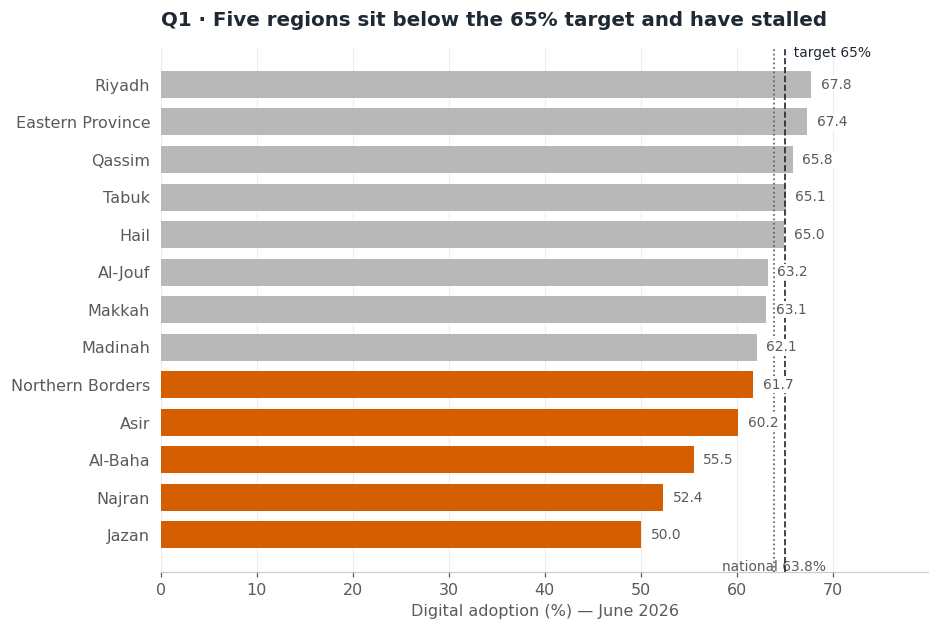

/home/claude/work/pkg/notebooks/out/lab2_q2_trend.png


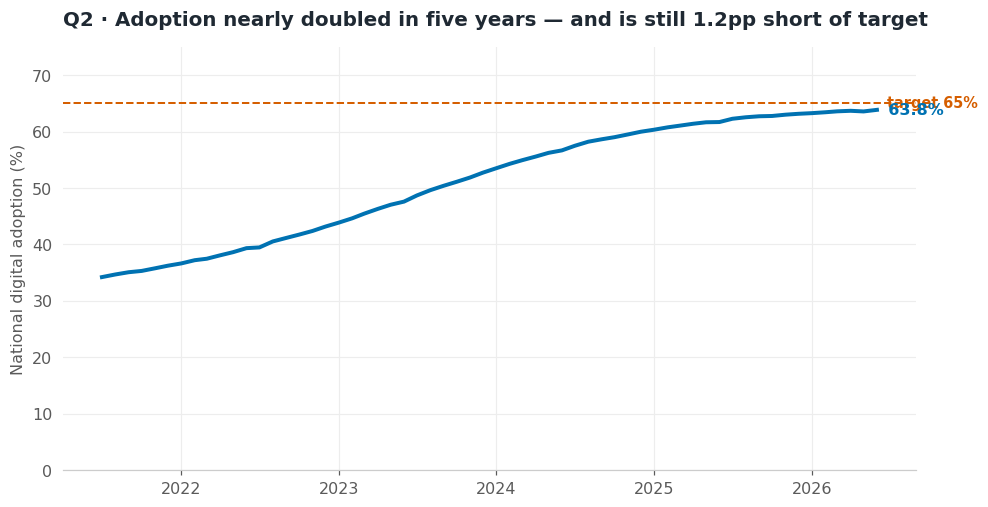

/home/claude/work/pkg/notebooks/out/lab2_q3_distribution.png


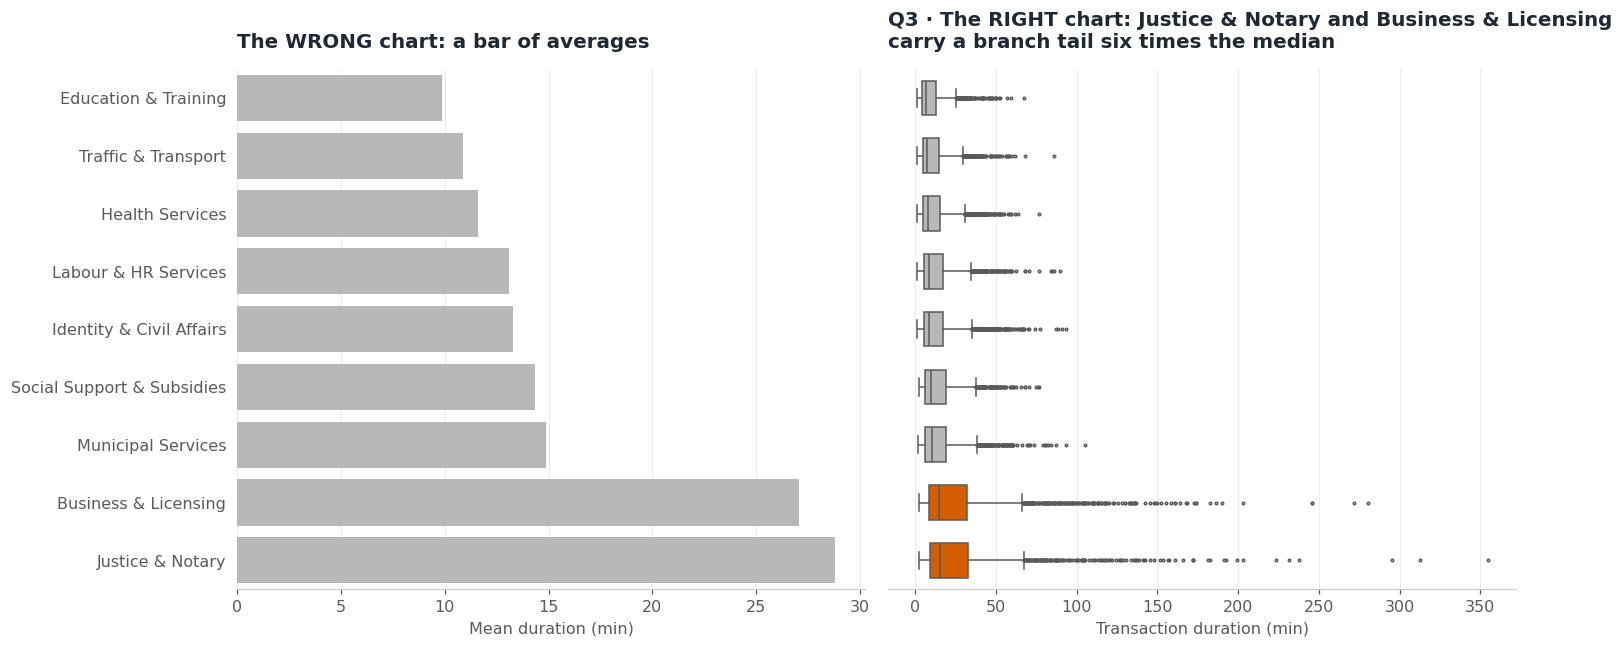

                            mean  median   p95    max
service_category                                     
Justice & Notary            28.8    15.6  98.8  354.7
Business & Licensing        27.0    14.5  96.5  280.7
Municipal Services          14.9    10.1  40.9  105.0
Social Support & Subsidies  14.4     9.8  38.7   76.8
Identity & Civil Affairs    13.3     8.6  38.6   93.4
Labour & HR Services        13.1     8.5  37.7   89.5
Health Services             11.6     7.8  33.0   76.8
Traffic & Transport         10.9     7.4  29.2   86.1
Education & Training         9.9     6.6  27.2   67.4


/home/claude/work/pkg/notebooks/out/lab2_q4_scatter.png


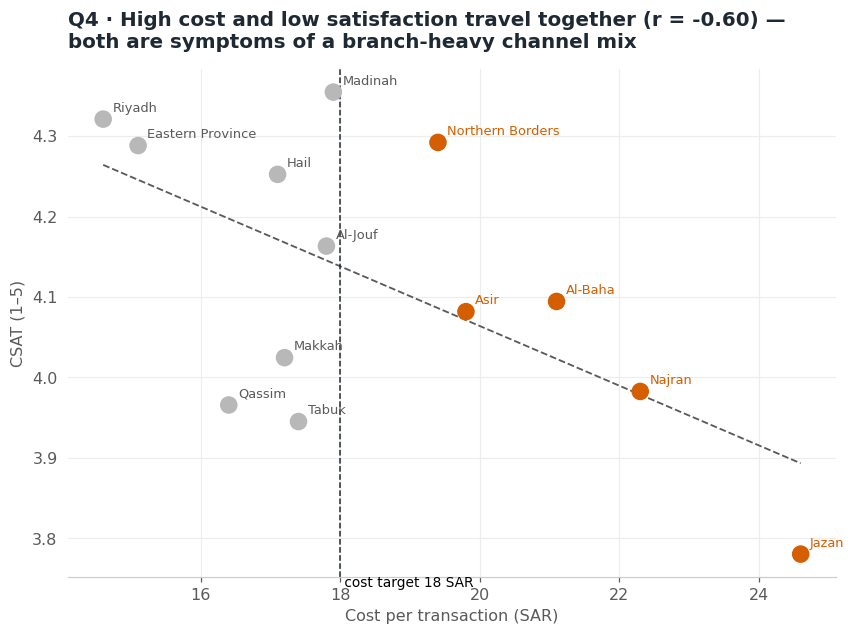

Pearson r = -0.601


In [4]:
latest = df[df.month == df.month.max()]

# ---------- Q1 — comparison / ranking ----------------------------------
q1 = (tv.by(latest, "region", "digital_adoption_pct")
        .rename(columns={"digital_adoption_pct": "adoption_pct"}))
national = tv.adoption(latest)

fig, ax = plt.subplots(figsize=(9, 6.2))
tv.sorted_bar(q1, "region", "adoption_pct", highlight=tv.STALLED,
              title="Q1 · Five regions sit below the 65% target and have stalled",
              xlabel="Digital adoption (%) — June 2026",
              reference=tv.TARGET_ADOPTION, reference_label="target 65%", ax=ax)
ax.axvline(national, color=tv.GREY_DARK, ls=":", lw=1.1, zorder=3.4)
ax.text(national, -0.95, f"national {national:.1f}%", fontsize=9,
        color=tv.GREY_DARK, ha="center")
print(tv.save_fig(fig, "lab2_q1_sorted_bar")); plt.show()

# ---------- Q2 — trend over time ---------------------------------------
q2 = tv.by(df, "month", "digital_adoption_pct").sort_values("month")
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(q2.month, q2.digital_adoption_pct, color=tv.ACCENT_2, lw=2.6)
ax.axhline(tv.TARGET_ADOPTION, color=tv.ACCENT, ls="--", lw=1.3)
ax.text(q2.month.iloc[-1], tv.TARGET_ADOPTION, "  target 65%", color=tv.ACCENT,
        va="center", fontsize=9.5, weight="bold")
ax.text(q2.month.iloc[-1], q2.digital_adoption_pct.iloc[-1],
        f"  {q2.digital_adoption_pct.iloc[-1]:.1f}%", color=tv.ACCENT_2,
        va="center", weight="bold")                     # direct label, no legend
ax.set_ylim(0, 75)
ax.set_ylabel("National digital adoption (%)")
ax.set_title("Q2 · Adoption nearly doubled in five years — and is still 1.2pp short of target")
print(tv.save_fig(fig, "lab2_q2_trend")); plt.show()

# ---------- Q3 — distribution -------------------------------------------
order = (txn.groupby("service_category").duration_min.quantile(.95)
            .sort_values().index.tolist())
fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
means = txn.groupby("service_category").duration_min.mean().reindex(order)
axs[0].barh(means.index, means.values, color=tv.GREY)
axs[0].set_title("The WRONG chart: a bar of averages")
axs[0].set_xlabel("Mean duration (min)")
axs[0].grid(axis="y", visible=False)

sns.boxplot(data=txn, y="service_category", x="duration_min", order=order,
            ax=axs[1], color=tv.GREY, fliersize=1.6, width=.6,
            linecolor=tv.GREY_DARK, linewidth=1)
for i, cat in enumerate(order):                       # one accent: the long tails
    if cat in ("Justice & Notary", "Business & Licensing"):
        axs[1].patches[i].set_facecolor(tv.ACCENT)
axs[1].set_title("Q3 · The RIGHT chart: Justice & Notary and Business & Licensing\n"
                 "carry a branch tail six times the median")
axs[1].set_xlabel("Transaction duration (min)")
axs[1].set_ylabel("")
axs[1].grid(axis="y", visible=False)
fig.tight_layout()
print(tv.save_fig(fig, "lab2_q3_distribution")); plt.show()

print(txn.groupby("service_category").duration_min
         .agg(mean="mean", median="median", p95=lambda s: s.quantile(.95), max="max")
         .round(1).sort_values("p95", ascending=False).to_string())

# ---------- Q4 — relationship -------------------------------------------
q4 = (tv.by(latest, "region", "csat")
        .merge(tv.by(latest, "region", "cost_per_txn_sar")))
r = q4.csat.corr(q4.cost_per_txn_sar)
m, b = np.polyfit(q4.cost_per_txn_sar, q4.csat, 1)

fig, ax = plt.subplots(figsize=(9, 6))
colors = tv.highlight_palette(q4.region, tv.STALLED)
ax.scatter(q4.cost_per_txn_sar, q4.csat, s=110, color=colors, zorder=3)
xs = np.linspace(q4.cost_per_txn_sar.min(), q4.cost_per_txn_sar.max(), 20)
ax.plot(xs, m * xs + b, color=tv.GREY_DARK, ls="--", lw=1.2, zorder=2)
for _, row in q4.iterrows():                           # direct labels, no legend
    ax.annotate(row.region, (row.cost_per_txn_sar, row.csat),
                xytext=(6, 5), textcoords="offset points", fontsize=8.5,
                color=tv.ACCENT if row.region in tv.STALLED else tv.GREY_DARK)
ax.axvline(tv.TARGET_COST, color=tv.INK, ls="--", lw=1)
ax.text(tv.TARGET_COST, q4.csat.min() - .04, " cost target 18 SAR", fontsize=9)
ax.set_xlabel("Cost per transaction (SAR)"); ax.set_ylabel("CSAT (1–5)")
ax.set_title(f"Q4 · High cost and low satisfaction travel together (r = {r:.2f}) —\n"
             "both are symptoms of a branch-heavy channel mix")
print(tv.save_fig(fig, "lab2_q4_scatter")); plt.show()
print(f"Pearson r = {r:.3f}")

**Instructor commentary.** Q3 is the highest-value moment in Module 2 and the panels are
deliberately side by side. On means, Justice & Notary (28.8 min) and Municipal Services
(14.9 min) look like an ordinary 2× difference. The box plot shows something else
entirely: a p95 of 99 minutes against 41, and a maximum of 355 minutes. That tail is
branch-handled casework, and it is the *operational* story — the average erased it. Say
out loud: **the chart choice changed the conclusion.**

Q4 deserves a caution. r = −0.60 is a real association but it is not causal: cheap
regions and satisfied regions are both regions with a digital-heavy channel mix. A dual
axis would have implied causation by making two lines cross; the scatter refuses to.

---
## Task 4 — The reference lines *(5 min)*

A reference line turns a chart of numbers into a chart of **judgements**. Q1 gets the
national mean, Q2 gets the 65% target. Both are already in the charts above — this task
is to *verify* them and to show what the chart looks like without.

/home/claude/work/pkg/notebooks/out/lab2_reference_lines.png


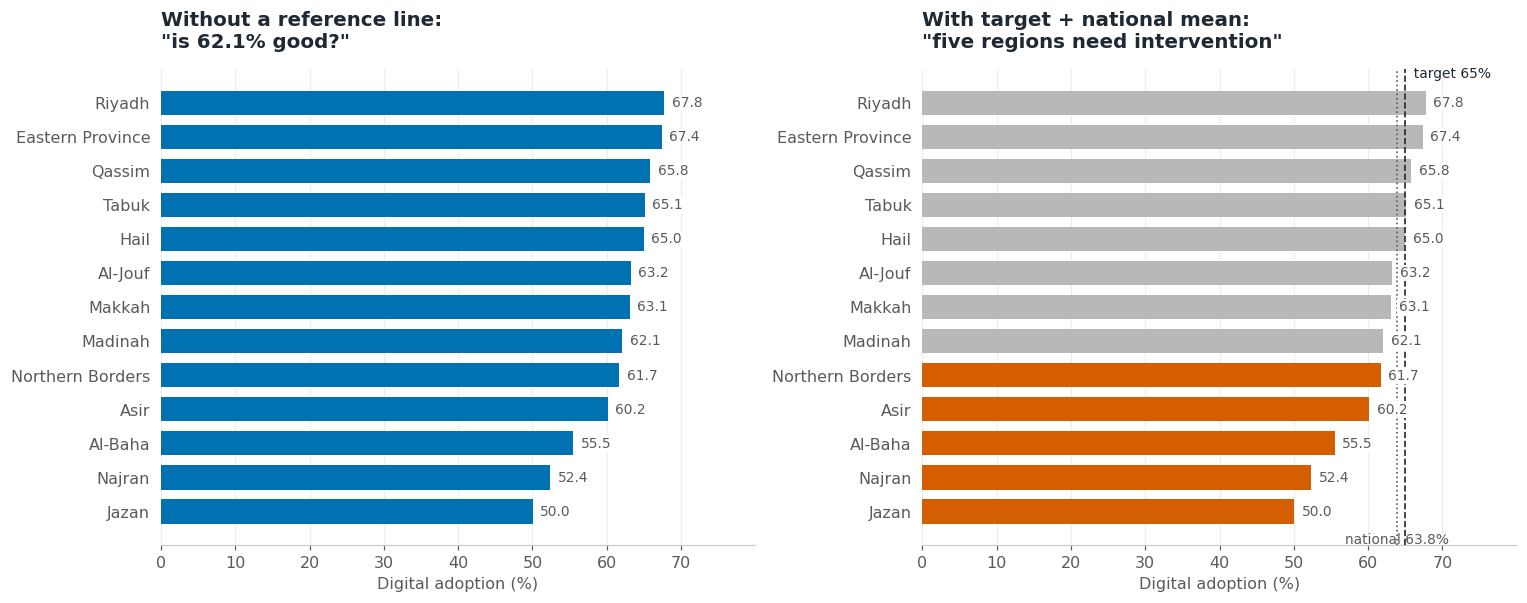

national mean (user-weighted) : 63.84%
adoption target (KPI-01)      : 65.0%
regions below target          : 9  (KPI-08 = 9)
of which stalled (Tier 1)     : 5


In [5]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5.6))

tv.sorted_bar(q1, "region", "adoption_pct", title="Without a reference line:\n"
              "\"is 62.1% good?\"", xlabel="Digital adoption (%)", ax=axs[0])
tv.sorted_bar(q1, "region", "adoption_pct", highlight=tv.STALLED,
              title="With target + national mean:\n\"five regions need intervention\"",
              xlabel="Digital adoption (%)",
              reference=tv.TARGET_ADOPTION, reference_label="target 65%", ax=axs[1])
axs[1].axvline(national, color=tv.GREY_DARK, ls=":", lw=1.1, zorder=3.4)
axs[1].text(national, -0.95, f"national {national:.1f}%", fontsize=9,
            color=tv.GREY_DARK, ha="center")
fig.tight_layout()
print(tv.save_fig(fig, "lab2_reference_lines")); plt.show()

print(f"national mean (user-weighted) : {national:.2f}%")
print(f"adoption target (KPI-01)      : {tv.TARGET_ADOPTION:.1f}%")
print(f"regions below target          : {(q1.adoption_pct < tv.TARGET_ADOPTION).sum()}  (KPI-08 = 9)")
print(f"of which stalled (Tier 1)     : {len(tv.STALLED)}")
assert (q1.adoption_pct < tv.TARGET_ADOPTION).sum() == 9

**Instructor commentary.** The count is worth pausing on. **Nine** regions are below the
65% target, but only **five** are *stalled* (Tier 1, under 0.08pp/month). The other four
are rising and will cross on their own. A chart that only showed "below target" would
send improvement teams to nine regions; the trend classification is what narrows the ask
to five. Note also that the INSTRUCTOR_PACKAGE's own expected-output blocks sometimes say
"three regions" — that is the count of *severe* laggards more than 9pp below target
(Jazan, Najran, Al-Baha). Three counts, three meanings; say which one you mean.

---
## Task 5 — Q2 as an interactive Plotly line *(5 min)*

A preview of Module 4. Hover shows the exact monthly value; the target stays a reference
line, not a second series. Nothing about the *design* changes because the medium changed.

In [6]:
import plotly.graph_objects as go
import plotly.io as pio

figp = go.Figure()
figp.add_trace(go.Scatter(
    x=q2.month, y=q2.digital_adoption_pct, mode="lines",
    line=dict(color=tv.ACCENT_2, width=3), name="National",
    hovertemplate="%{x|%b %Y}<br>adoption <b>%{y:.1f}%</b><extra></extra>"))
figp.add_hline(y=tv.TARGET_ADOPTION, line_dash="dash", line_color=tv.ACCENT,
               annotation_text="target 65%", annotation_position="top left")
figp.add_annotation(x=q2.month.iloc[-1], y=q2.digital_adoption_pct.iloc[-1],
                    text=f"<b>{q2.digital_adoption_pct.iloc[-1]:.1f}%</b>",
                    showarrow=False, xshift=34, font=dict(color=tv.ACCENT_2))
figp.update_layout(
    template="plotly_white", height=460, showlegend=False,
    title="Q2 · National digital adoption vs the 65% target (hover for exact values)",
    yaxis=dict(title="Digital adoption (%)", range=[0, 75]), xaxis=dict(title=""))

res = tv.save_plotly(figp, "lab2_q2_interactive", width=1100, height=460)
print("HTML:", res["html"])
print("PNG :", res["png"] or f"not written ({res.get('png_error')})"
      "  <- the matplotlib mirror lab2_q2_trend.png covers the slide deck")
figp.show()

HTML: /home/claude/work/pkg/notebooks/out/lab2_q2_interactive.html
PNG : not written (RuntimeError: )  <- the matplotlib mirror lab2_q2_trend.png covers the slide deck


**Instructor commentary.** Two things to name while this renders. First: the target is a
`hline`, not a second trace — if it were a series it would acquire a legend entry and
compete for attention with the data. Second: interactivity added *hover precision*, which
is genuinely useful, but it did not change a single design decision. Interactivity is a
delivery mechanism, not a design strategy — a bad chart with tooltips is still a bad chart.

---
## Task 6 — Export, and kill a dual axis with indexed lines *(5 min)*

The Module 1 case study's other villain was a **dual-axis** line overlaying satisfaction
(1–5) and cost (SAR), scaled so the lines crossed — which the committee read as causation.

The fix is not a prettier dual axis. It is to **index both series to their first month =
100** so they share one honest axis. Build the villain and the fix side by side, then
export everything.

/home/claude/work/pkg/notebooks/out/lab2_indexed_lines.png


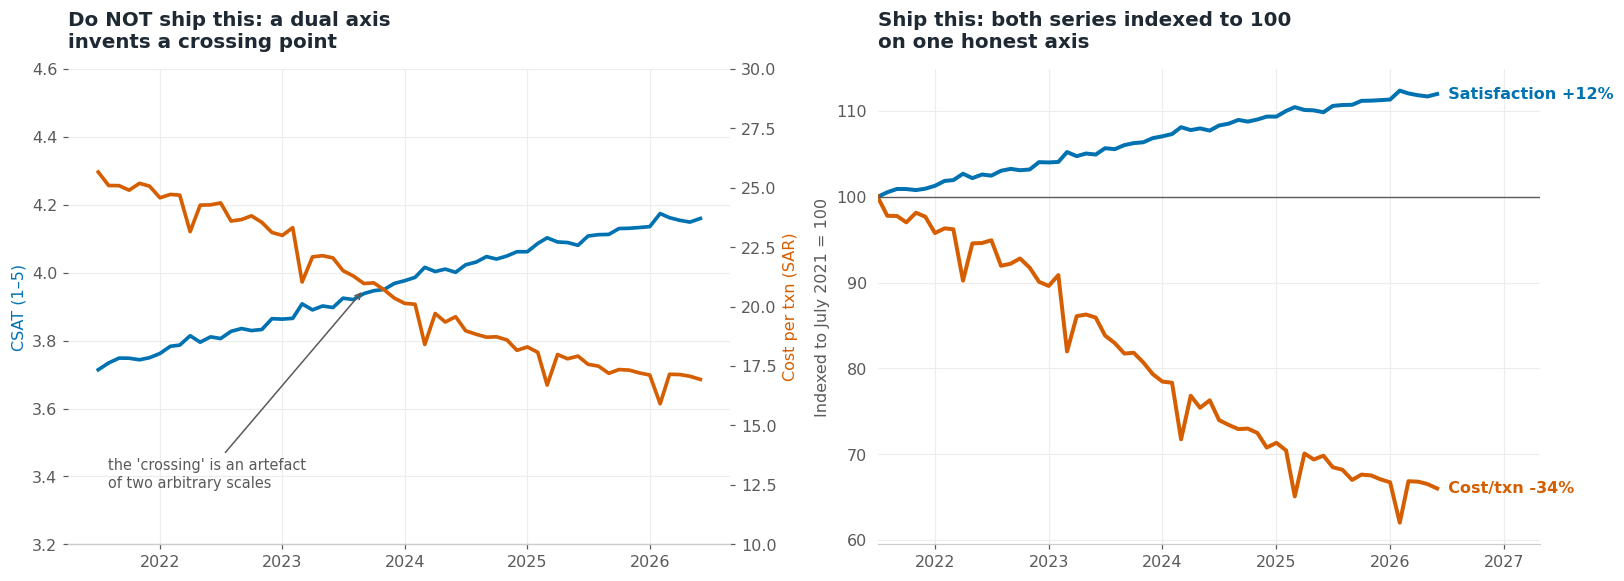

Since programme start: satisfaction +12%, cost per transaction -34%

Exported:
  lab2_indexed_lines.png
  lab2_q1_sorted_bar.png
  lab2_q2_interactive.html
  lab2_q2_trend.png
  lab2_q3_distribution.png
  lab2_q4_scatter.png
  lab2_reference_lines.png


In [7]:
nat = (tv.by(df, "month", "csat")
         .merge(tv.by(df, "month", "cost_per_txn_sar"))
         .sort_values("month").set_index("month"))
idx = nat / nat.iloc[0] * 100

fig, axs = plt.subplots(1, 2, figsize=(15, 5.4))

# ---- the villain: a dual axis, scaled to manufacture a crossing ----------
a = axs[0]
a.plot(nat.index, nat.csat, color=tv.ACCENT_2, lw=2.4)
a.set_ylim(3.2, 4.6); a.set_ylabel("CSAT (1–5)", color=tv.ACCENT_2)
b = a.twinx()
b.plot(nat.index, nat.cost_per_txn_sar, color=tv.ACCENT, lw=2.4)
b.set_ylim(10, 30); b.set_ylabel("Cost per txn (SAR)", color=tv.ACCENT)
b.spines[["top"]].set_visible(False); b.grid(False)
a.set_title("Do NOT ship this: a dual axis\ninvents a crossing point")
a.annotate("the 'crossing' is an artefact\nof two arbitrary scales",
           xy=(nat.index[26], 3.95), xytext=(0.06, 0.12), textcoords="axes fraction",
           fontsize=9.5, color=tv.GREY_DARK,
           arrowprops=dict(arrowstyle="->", color=tv.GREY_DARK))

# ---- the fix: indexed lines on ONE axis ---------------------------------
c = axs[1]
c.plot(idx.index, idx.csat, color=tv.ACCENT_2, lw=2.6)
c.plot(idx.index, idx.cost_per_txn_sar, color=tv.ACCENT, lw=2.6)
c.axhline(100, color=tv.GREY_DARK, lw=0.9)
c.text(idx.index[-1], idx.csat.iloc[-1], f"  Satisfaction +{idx.csat.iloc[-1]-100:.0f}%",
       color=tv.ACCENT_2, va="center", weight="bold")
c.text(idx.index[-1], idx.cost_per_txn_sar.iloc[-1],
       f"  Cost/txn {idx.cost_per_txn_sar.iloc[-1]-100:.0f}%",
       color=tv.ACCENT, va="center", weight="bold")
c.set_ylabel("Indexed to July 2021 = 100")
c.set_xlim(idx.index[0], idx.index[-1] + pd.Timedelta(days=330))
c.set_title("Ship this: both series indexed to 100\non one honest axis")
fig.tight_layout()
print(tv.save_fig(fig, "lab2_indexed_lines")); plt.show()

print(f"Since programme start: satisfaction {idx.csat.iloc[-1]-100:+.0f}%, "
      f"cost per transaction {idx.cost_per_txn_sar.iloc[-1]-100:+.0f}%")

exported = sorted(p.name for p in tv.OUT.glob("lab2_*"))
print("\nExported:", *exported, sep="\n  ")

**Instructor commentary.** The left panel is the exact chart that made the Tayseer
Steering Committee conclude that rising cost *caused* rising satisfaction. Nothing in it
is factually false — both series are drawn accurately — and that is precisely why it is
dangerous. The right panel carries the same two series, and the honest reading is the
opposite: satisfaction rose **12%** while unit cost fell **34%**, because both were
driven by the shift from branches to the app. One axis, two direct labels, no legend,
and the title states the argument.

---
## Lab 2 complete

| Question | Chosen chart | Principles | Anti-pattern avoided | Verdict |
|---|---|---|---|---|
| Q1 ranking | Sorted bar + target + national mean | 5/5 | not a pie, not a choropleth | ship |
| Q2 trend | Line + target reference | 5/5 | not clustered bars, not truncated | ship |
| Q3 distribution | Box plot on 20k transactions | 5/5 | not a bar of averages | ship |
| Q4 relationship | Scatter + trend + direct labels | 5/5 | not a dual axis | ship |
| bonus | Indexed lines | 5/5 | dual axis retired | ship |

**Reproduced package figures:** cost per transaction **25.66 → 16.94 SAR (−34%)**,
CSAT **3.71 → 4.16 (+12%)**, adoption **34.2% → 63.8%**, nine regions below target of
which five stalled.

**Figures written to `notebooks/out/`:** `lab2_q1_sorted_bar.png` ·
`lab2_q2_trend.png` · `lab2_q3_distribution.png` · `lab2_q4_scatter.png` ·
`lab2_reference_lines.png` · `lab2_indexed_lines.png` · `lab2_q2_interactive.html`

Next: **Lab 3 — Before/After Redesign.**

---

## Section 2b — Normalisation and the per-capita flip  *(35 min · Case C)*

The committee asked "who is underserved?" and was handed a chart that answers "where is the work?".
Those are different questions with different denominators, and the ranking inverts between them.

Data: `tayseer_services.csv`, `dim_regions.csv`, and `regional_equity_latest.csv` (the reference answer).


### Task 1 · (5 min) Two denominators

Compute, for the latest month: total **digital** transactions by region (Mobile App + Web Portal),
and the same figure divided by `population_2025`, expressed per 1,000 residents.

In [8]:
import tayseer_viz as tv
import pandas as pd, numpy as np, matplotlib.pyplot as plt
tv.apply_theme()

df   = tv.load_facts()
dims = tv.load("dim_regions.csv")
chan = tv.load("dim_channels.csv")

DIGITAL = chan.loc[chan.is_digital.astype(str).str.lower().isin(["yes", "true"]), "channel"].tolist()
latest  = df[df.month == df.month.max()]

pop = dims.set_index("region")["population_2025"]
vol = (latest[latest.channel.isin(DIGITAL)]
       .groupby("region")["transactions"].sum()
       .rename("digital_transactions"))

eq = vol.to_frame()
eq["population_2025"]      = pop
eq["digital_txn_per_1k"]   = eq.digital_transactions / eq.population_2025 * 1000
eq = eq.sort_values("digital_txn_per_1k")

national = eq.digital_transactions.sum() / eq.population_2025.sum() * 1000
print(f"Digital channels: {DIGITAL}")
print(f"National rate: {national:,.1f} digital transactions per 1,000 residents\n")
print(eq.round(1).to_string())

Digital channels: ['Mobile App', 'Web Portal']
National rate: 225.3 digital transactions per 1,000 residents

                  digital_transactions  population_2025  digital_txn_per_1k
region                                                                     
Jazan                           309528          1720000               180.0
Najran                          121463           660000               184.0
Al-Baha                          97087           500000               194.2
Asir                            489863          2310000               212.1
Madinah                         495518          2290000               216.4
Makkah                         2036556          9230000               220.6
Northern Borders                 88651           400000               221.6
Al-Jouf                         124477           560000               222.3
Qassim                          344768          1520000               226.8
Hail                            173014           76000

### Task 2 · (8 min) Rank twice, and measure the shift

Draw both as sorted horizontal bars with the five Tier-1 regions accented. Then compute `rank_shift`
and name the largest mover in each direction.

Jazan: #7 by volume -> #13 per capita
Northern Borders: #13 by volume -> #7 per capita

Reconciles with regional_equity_latest.csv (max delta 0.050)


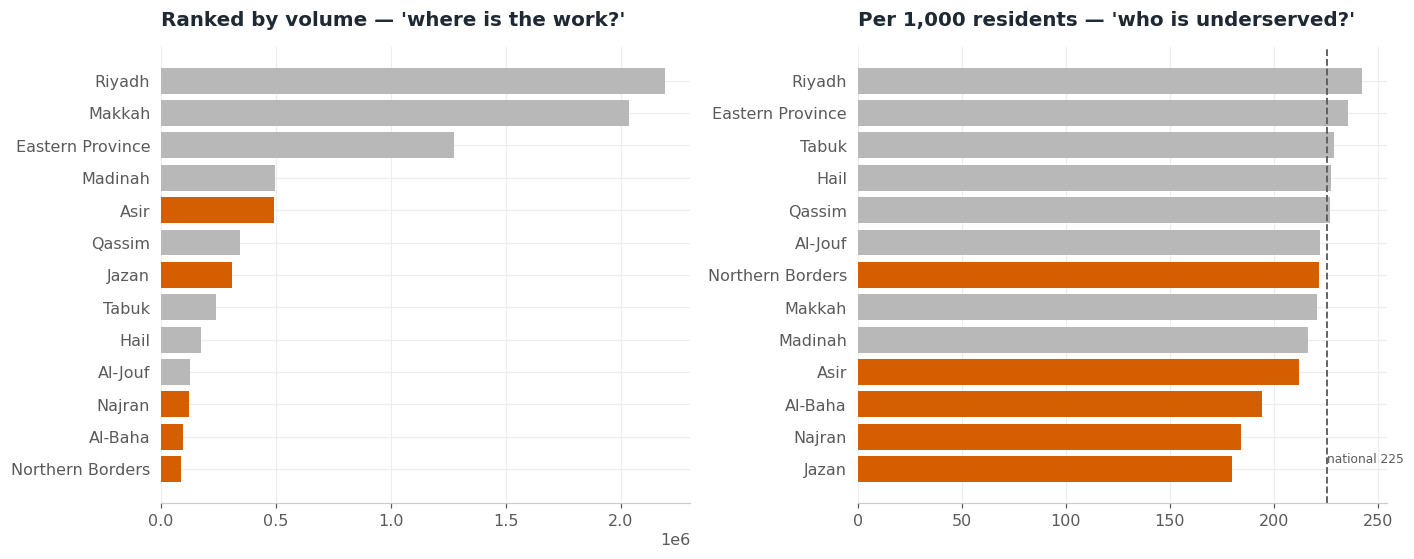

In [9]:
eq["rank_by_raw_volume"] = eq.digital_transactions.rank(ascending=False, method="min").astype(int)
eq["rank_by_per_capita"] = eq.digital_txn_per_1k.rank(ascending=False, method="min").astype(int)
eq["rank_shift"] = eq.rank_by_raw_volume - eq.rank_by_per_capita

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
for ax, col, title in ((axes[0], "digital_transactions", "Ranked by volume — 'where is the work?'"),
                       (axes[1], "digital_txn_per_1k",   "Per 1,000 residents — 'who is underserved?'")):
    d = eq.sort_values(col)
    colours = [tv.ACCENT if r in tv.STALLED else tv.GREY for r in d.index]
    ax.barh(d.index, d[col], color=colours)
    ax.set_title(title, loc="left")
    ax.spines[["top", "right"]].set_visible(False)
axes[1].axvline(national, color=tv.GREY_DARK, ls="--", lw=1.2)
axes[1].annotate(f"national {national:,.0f}", (national, 0.2), fontsize=8, color=tv.GREY_DARK)
fig.tight_layout()
tv.save_fig(fig, "lab2b_rank_flip")

down = eq.rank_shift.idxmin(); up = eq.rank_shift.idxmax()
print(f"{down}: #{eq.loc[down,'rank_by_raw_volume']} by volume -> #{eq.loc[down,'rank_by_per_capita']} per capita")
print(f"{up}: #{eq.loc[up,'rank_by_raw_volume']} by volume -> #{eq.loc[up,'rank_by_per_capita']} per capita")

ref = tv.load("regional_equity_latest.csv").set_index("region")
delta = (eq.digital_txn_per_1k - ref.digital_txn_per_1k_pop).abs().max()
assert delta < 0.6, f"per-capita rate disagrees with the shipped scorecard by {delta:.2f}"
print(f"\nReconciles with regional_equity_latest.csv (max delta {delta:.3f})")

### Task 3 · (7 min) What is this map a map OF?

Draw the raw-count view as a *map-like* object — regions ordered by geography is enough here —
then answer in writing: what is a raw-count choropleth actually a map of? Keep the answer.
It is the punchline of Case C.

corr(population, raw digital transactions) = 0.998

Answer: a raw-count choropleth of service volume is, to a very good approximation,
a population map with extra steps. It cannot answer a question about service level.


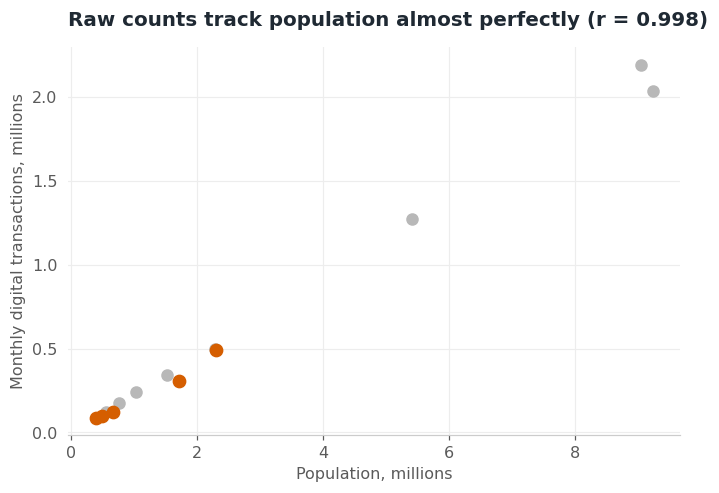

In [10]:
r = np.corrcoef(eq.population_2025, eq.digital_transactions)[0, 1]

fig, ax = plt.subplots(figsize=(6.4, 4.6))
ax.scatter(eq.population_2025 / 1e6, eq.digital_transactions / 1e6,
           s=52, color=tv.GREY, zorder=3)
for reg in tv.STALLED:
    ax.scatter(eq.loc[reg, "population_2025"] / 1e6,
               eq.loc[reg, "digital_transactions"] / 1e6, s=64, color=tv.ACCENT, zorder=4)
ax.set_xlabel("Population, millions"); ax.set_ylabel("Monthly digital transactions, millions")
ax.set_title(f"Raw counts track population almost perfectly (r = {r:.3f})", loc="left")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout(); tv.save_fig(fig, "lab2b_counts_are_population")

print(f"corr(population, raw digital transactions) = {r:.3f}")
print("\nAnswer: a raw-count choropleth of service volume is, to a very good approximation,")
print("a population map with extra steps. It cannot answer a question about service level.")

### Task 4 · (6 min) Lorenz and Gini — and whether they belong

Build the Lorenz curve of digital transactions against population and compute the Gini.
Then decide whether it goes in the deck. Justify the decision in one sentence — including if the answer is no.

Gini = 0.0372

Verdict: leave it out. A Gini near zero says transaction VOLUME is distributed in
proportion to population, which is true and irrelevant. The inequality the committee
asked about is in the LEVEL of adoption (50.0% to 67.8%), and the Lorenz curve cannot show it.


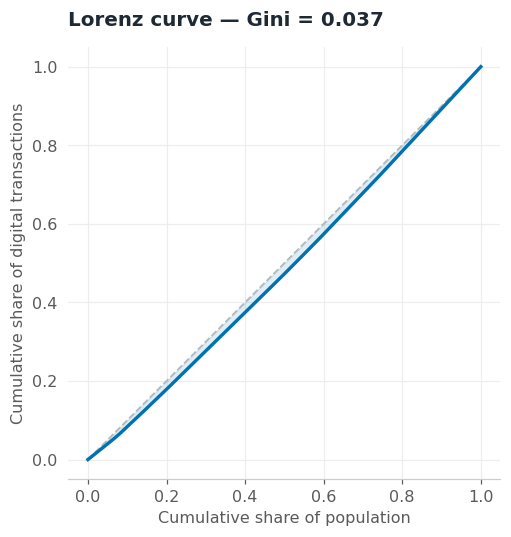

In [11]:
lz = eq.sort_values("digital_txn_per_1k").copy()
lz["cum_pop"] = lz.population_2025.cumsum() / lz.population_2025.sum()
lz["cum_txn"] = lz.digital_transactions.cumsum() / lz.digital_transactions.sum()

x = np.concatenate([[0.0], lz.cum_pop.values]); y = np.concatenate([[0.0], lz.cum_txn.values])
gini = 1 - np.sum((x[1:] - x[:-1]) * (y[1:] + y[:-1]))

fig, ax = plt.subplots(figsize=(5.2, 5.0))
ax.plot([0, 1], [0, 1], color=tv.GREY, ls="--", lw=1.2)
ax.plot(x, y, color=tv.CATEGORICAL[0], lw=2.2)
ax.fill_between(x, y, x, color=tv.CATEGORICAL[0], alpha=0.12)
ax.set_xlabel("Cumulative share of population"); ax.set_ylabel("Cumulative share of digital transactions")
ax.set_title(f"Lorenz curve — Gini = {gini:.3f}", loc="left"); ax.set_aspect("equal")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout(); tv.save_fig(fig, "lab2b_lorenz")

print(f"Gini = {gini:.4f}")
print("\nVerdict: leave it out. A Gini near zero says transaction VOLUME is distributed in")
print("proportion to population, which is true and irrelevant. The inequality the committee")
print("asked about is in the LEVEL of adoption (50.0% to 67.8%), and the Lorenz curve cannot show it.")
assert gini < 0.10, "expected near-equality of volume share"

### Task 5 · (6 min) The subtitle that states the denominator

Write the chart subtitle in under 15 words. It must carry the measure, the denominator, the month
and the target. Then (Task 6, 3 min) have your partner read only the subtitle and describe the chart back to you.

Digital transactions per 1,000 residents, June 2026 — national 225 
(10 words)



Lab 2b complete. Figures written to notebooks/out/.


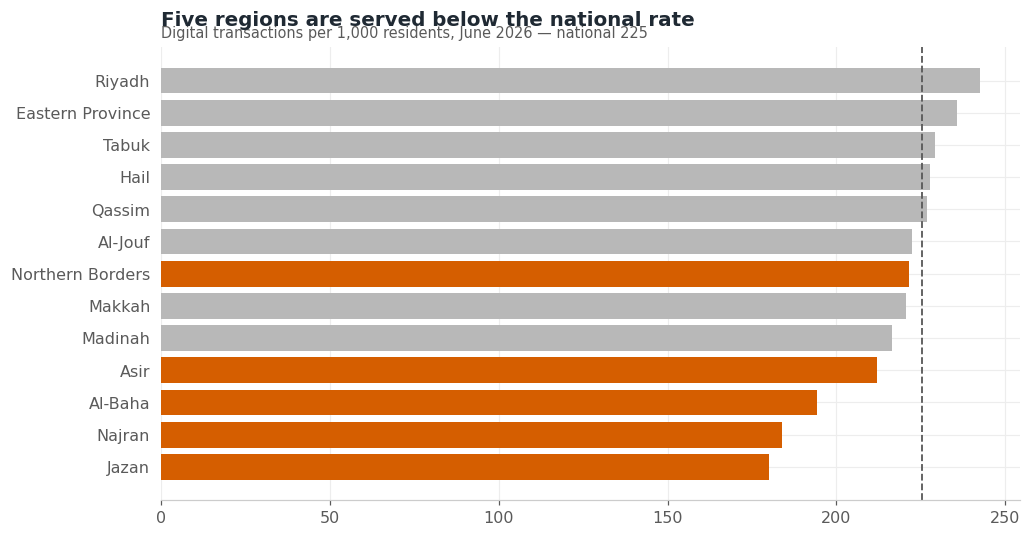

In [12]:
month = df.month.max().strftime("%B %Y")
subtitle = f"Digital transactions per 1,000 residents, {month} — national {national:,.0f}"
print(subtitle, f"\n({len(subtitle.split())} words)")

fig, ax = plt.subplots(figsize=(9.5, 5.0))
d = eq.sort_values("digital_txn_per_1k")
ax.barh(d.index, d.digital_txn_per_1k,
        color=[tv.ACCENT if r in tv.STALLED else tv.GREY for r in d.index])
ax.axvline(national, color=tv.GREY_DARK, ls="--", lw=1.2)
ax.set_title("Five regions are served below the national rate", loc="left",
             fontsize=13, fontweight="bold", color=tv.INK)
ax.text(0, 1.02, subtitle, transform=ax.transAxes, fontsize=9.5, color=tv.GREY_DARK)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout(); tv.save_fig(fig, "lab2b_final_normalised")

assert len(subtitle.split()) < 15, "the subtitle must be under 15 words"
print("\nLab 2b complete. Figures written to notebooks/out/.")